In [1]:
import open3d as o3d
import numpy as np

pcd_data = o3d.data.DemoICPPointClouds()
source = o3d.io.read_point_cloud(pcd_data.paths[0])   
target = o3d.io.read_point_cloud(pcd_data.paths[2])   

flip_transform = np.array([[1, 0, 0, 0],
                           [0,-1, 0, 0],
                           [0, 0,-1, 0],
                           [0, 0, 0, 1]])
target.transform(flip_transform)

source_down = source.voxel_down_sample(0.02)
target_down = target.voxel_down_sample(0.02)

source_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    source_down, o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=50))

target_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    target_down, o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=50))

global_distance = 0.1  

result_global = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_down, target_down,
    source_fpfh, target_fpfh,
    True, 
    global_distance,
    o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
    4,
    [
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(global_distance)
    ],
    o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999)
)

print("Global alignment done")
source.transform(result_global.transformation)

o3d.visualization.draw_geometries([source, target], window_name="After RANSAC (before ICP)")

threshold = 0.05  
icp_iteration = 500

vis = o3d.visualization.Visualizer()
vis.create_window()
vis.add_geometry(source)
vis.add_geometry(target)

for i in range(icp_iteration):
    reg_p2l = o3d.pipelines.registration.registration_icp(
        source, target, threshold, np.identity(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=1)
    )
    source.transform(reg_p2l.transformation)
    vis.update_geometry(source)
    vis.poll_events()
    vis.update_renderer()
    print(f"ICP iter: {i}")

vis.destroy_window()



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Global alignment done
ICP iter: 0
ICP iter: 1
ICP iter: 2
ICP iter: 3
ICP iter: 4
ICP iter: 5
ICP iter: 6
ICP iter: 7
ICP iter: 8
ICP iter: 9
ICP iter: 10
ICP iter: 11
ICP iter: 12
ICP iter: 13
ICP iter: 14
ICP iter: 15
ICP iter: 16
ICP iter: 17
ICP iter: 18
ICP iter: 19
ICP iter: 20
ICP iter: 21
ICP iter: 22
ICP iter: 23
ICP iter: 24
ICP iter: 25
ICP iter: 26
ICP iter: 27
ICP iter: 28
ICP iter: 29
ICP iter: 30
ICP iter: 31
ICP iter: 32
ICP iter: 33
ICP iter: 34
ICP iter: 35
ICP iter: 36
ICP iter: 37
ICP iter: 38
ICP iter: 39
ICP iter: 40
ICP iter: 41
ICP iter: 42
ICP iter: 43
ICP iter: 44
ICP iter: 45
ICP iter: 46
ICP iter: 47
ICP iter: 48
ICP iter: 49
ICP iter: 50
ICP iter: 51
ICP iter: 52
ICP iter: 53
ICP iter: 54
ICP iter: 55
ICP iter: 56
ICP iter: 57
ICP iter: 58
ICP iter: 59
ICP iter: 60
ICP iter: 61
ICP iter: 62


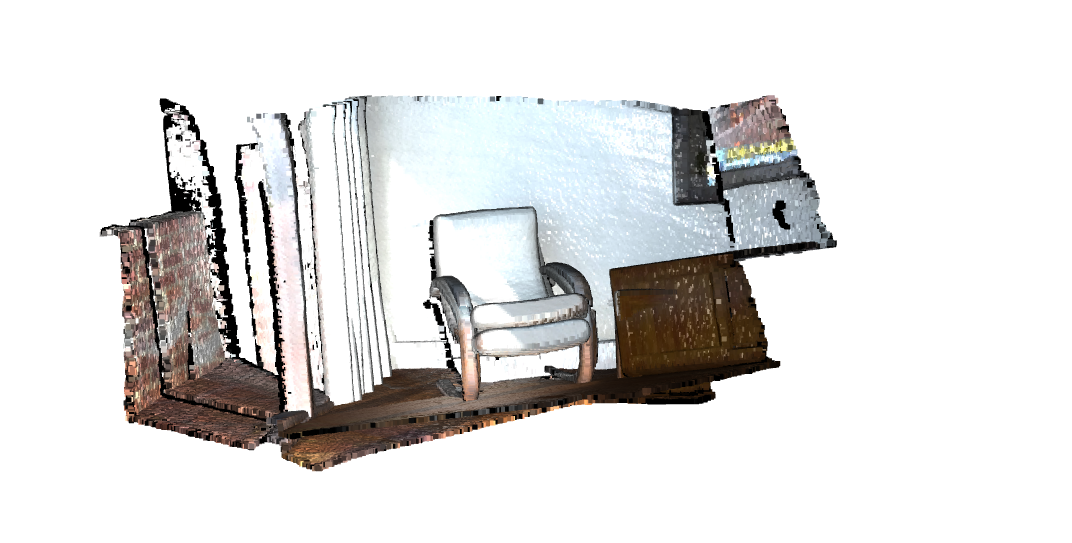

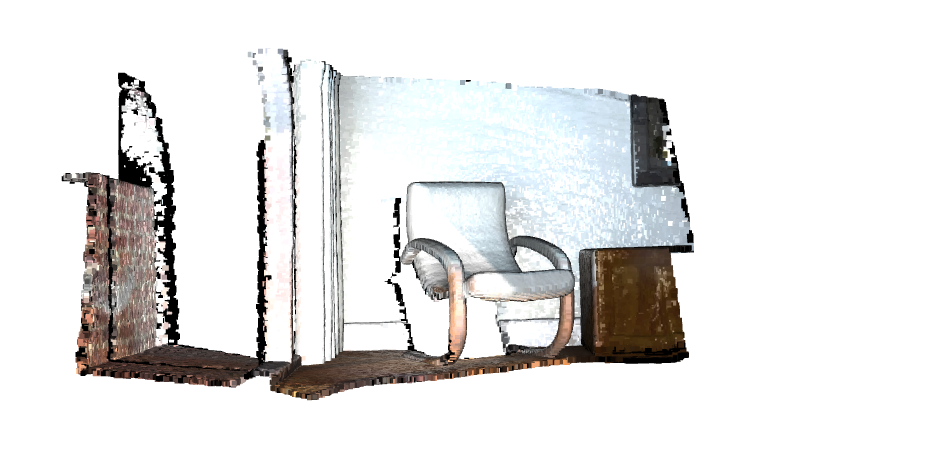